In [30]:
# importing needed packages
import pandas as pd
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
import os
from scipy import stats
# import cartopy.crs as ccrs
# import cartopy.feature as cfeature
import statsmodels.api as sm
import statsmodels.formula.api as smf

In [31]:
# # read in the cleaned CSV with data from central valley stations
# path = 'E:/Central Valley Fog/CV_rows_codes.csv'
# if os.path.exists(path):
#     CV_rows = pd.read_csv(path, low_memory = False)
# else:
#     path = '/Volumes/disk1/Central Valley Fog/CV_rows_codes.csv'
#     CV_rows = pd.read_csv(path, low_memory = False)

# print(CV_rows)

In [32]:
# read in the cleaned CSV with data from central valley stations
path = 'E:/Central Valley Fog/CV_rows_w_zerovis.csv'
if os.path.exists(path):
    CV_rows = pd.read_csv(path, low_memory = False)
else:
    path = '/Volumes/disk1/Central Valley Fog/CV_rows_w_zerovis.csv'
    CV_rows = pd.read_csv(path, low_memory = False)

print(CV_rows)

           STATION_ID  LATITUDE  LONGITUDE                 DATE  \
0         USM00074917   35.1170  -119.3000  1941-12-01 00:00:00   
1         USM00074917   35.1170  -119.3000  1941-12-01 01:00:00   
2         USM00074917   35.1170  -119.3000  1941-12-01 02:00:00   
3         USM00074917   35.1170  -119.3000  1941-12-01 03:00:00   
4         USM00074917   35.1170  -119.3000  1941-12-01 04:00:00   
...               ...       ...        ...                  ...   
10821797  USW00024257   40.5175  -122.2986  2026-06-20 04:53:00   
10821798  USW00024257   40.5175  -122.2986  2026-06-20 05:53:00   
10821799  USW00024257   40.5175  -122.2986  2026-06-20 06:53:00   
10821800  USW00024257   40.5175  -122.2986  2026-06-20 07:53:00   
10821801  USW00024257   40.5175  -122.2986  2026-06-20 08:53:00   

          HourlyPrecipitation  HourlyVisibility  HourlyWindDirection  \
0                         0.0            16.093                  0.0   
1                         0.0            16.093    

In [33]:
max_visibility = CV_rows["HourlyVisibility"].max()
print("Maximum HourlyVisibility:", max_visibility)

Maximum HourlyVisibility: 16.093


In [34]:
count_over_160 = CV_rows[CV_rows["HourlyVisibility"] > 160].shape[0]
print("Rows with HourlyVisibility > 160:", count_over_160)

Rows with HourlyVisibility > 160: 0


In [35]:
# remove rows where HourlyVisibility is zero or missing
# CV_rows = CV_rows[CV_rows["HourlyVisibility"].gt(0)]

#fill in nan values in HourlyVisibility with 0
#CV_rows['HourlyVisibility'] = CV_rows['HourlyVisibility'].fillna(0)

print("CV_rows:", CV_rows.shape)

CV_rows: (10821802, 14)


In [36]:
# filtering based on precipiation to identify fog conditions
# filtering visibility threshold to identify outliers
CV_fog_rows = CV_rows[
    (CV_rows["HourlyPrecipitation"] < 0.03)
    & (CV_rows["HourlyVisibility"] < 17.000)
]

print("CV_fog_rows:", CV_fog_rows.shape) 

CV_fog_rows: (10429072, 14)


In [37]:
CV_rows_not_fog = CV_rows[
    ~((CV_rows["HourlyPrecipitation"] < 0.03) & (CV_rows["HourlyVisibility"] < 17.000))
]

print("Rows that do NOT meet fog filter:", CV_rows_not_fog.shape)
print(CV_rows_not_fog)

Rows that do NOT meet fog filter: (392730, 14)
           STATION_ID  LATITUDE  LONGITUDE                 DATE  \
31727     USW00093144  36.31667  -119.4000  2004-12-31 17:55:00   
31751     USW00093144  36.31667  -119.4000  2005-01-02 21:55:00   
31752     USW00093144  36.31667  -119.4000  2005-01-02 22:55:00   
31753     USW00093144  36.31667  -119.4000  2005-01-02 23:55:00   
31754     USW00093144  36.31667  -119.4000  2005-01-03 00:55:00   
...               ...       ...        ...                  ...   
10821776  USW00024257  40.51750  -122.2986  2026-06-19 11:15:00   
10821777  USW00024257  40.51750  -122.2986  2026-06-19 11:30:00   
10821778  USW00024257  40.51750  -122.2986  2026-06-19 11:53:00   
10821780  USW00024257  40.51750  -122.2986  2026-06-19 13:45:00   
10821781  USW00024257  40.51750  -122.2986  2026-06-19 13:53:00   

          HourlyPrecipitation  HourlyVisibility  HourlyWindDirection  \
31727                     0.3            16.093                100.0   
3175

In [38]:
# count_over_200 = CV_rows[CV_rows["HourlyVisibility"] > 200].shape[0]
# print("Rows with HourlyVisibility > 200:", count_over_200)

In [39]:
# Exclude days from April through October (months 4-10) in CV_fog_rows
CV_fog_rows = CV_fog_rows[~CV_fog_rows['month'].isin([4, 5, 6, 7, 8, 9, 10])]

print("CV_fog_rows after removing April-October:", CV_fog_rows.shape)

CV_fog_rows after removing April-October: (4526168, 14)


In [40]:
#counting days measured per year per station
fog_days_year = (
    CV_fog_rows
    .drop_duplicates(subset=['STATION', 'year', 'month', 'day'])
    .groupby(['STATION', 'year'], as_index=False)
    .size()
    .rename(columns={'size': 'fog_days'})
    .sort_values(['STATION', 'year'])
)

print(fog_days_year.head())

          STATION  year  fog_days
0  BAKERSFIELD AP  1928        66
1  BAKERSFIELD AP  1929       120
2  BAKERSFIELD AP  1930        80
3  BAKERSFIELD AP  1931       108
4  BAKERSFIELD AP  1932       152


In [41]:
# Find stations with data back to at least 1970
stations_pre1970 = (
    CV_rows.groupby('STATION')['year']
    .min()
    .loc[lambda s: s <= 1970]
    .index
    .tolist()
)

print(len(stations_pre1970), "stations with data back to at least 1970")
print(stations_pre1970)

# make dateframe with station locations
station_locations = (
    CV_rows[CV_rows['STATION'].isin(stations_pre1970)]
    .drop_duplicates(subset=['STATION'])
    .loc[:, ['STATION', 'LATITUDE', 'LONGITUDE']]
    .reset_index(drop=True)
)

19 stations with data back to at least 1970
['BAKERSFIELD AP', 'BEALE AFB', 'CASTLE AFB', 'FRESNO', 'FRESNO CHANDLER DOWNTOWN AP', 'FRESNO YOSEMITE INTL', 'GARDNER AAF', 'HAMMER AAF', 'LEMOORE REEVES NAS', 'LIVERMORE NAS', 'RED BLUFF MUNI AP', 'REDDING AP', 'SACRAMENTO AP ASOS', 'SACRAMENTO MATHER AFB', 'SACRAMENTO MCCLELLAN AFB', 'STOCKTON AP', 'TRAVIS FIELD AFB', 'VERNALIS NAVAL AUX', 'WILLIAMS CAA AIRPORT']


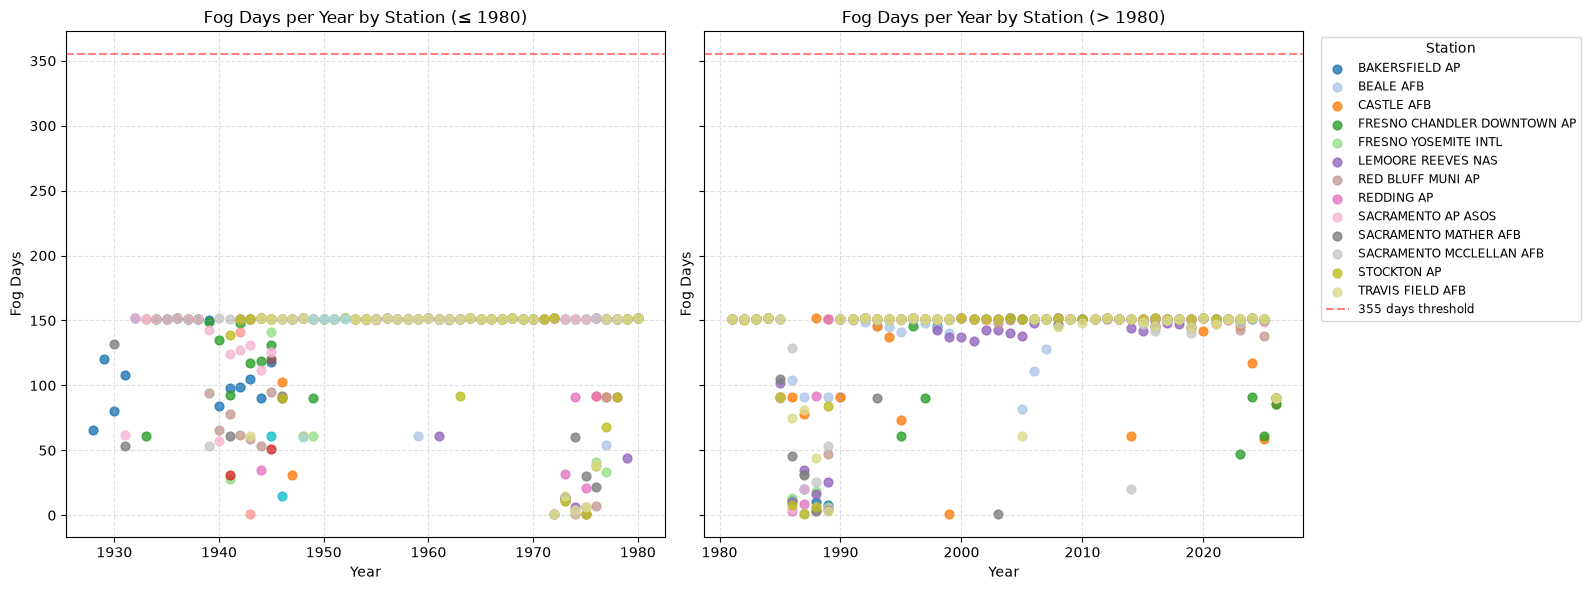

In [42]:
# plot the 'fog' days per year for the outliers for each station
# doing this in order to see where outlier years are
plot_stations = [st for st in stations_pre1970 if st in fog_days_year['STATION'].unique()]
colors = plt.cm.tab20(np.linspace(0, 1, len(plot_stations)))
color_map = dict(zip(plot_stations, colors))

# Make sure to only plot for stations with data back to at least 1970
fog_pre1970 = fog_days_year[fog_days_year['STATION'].isin(plot_stations)]

# Create a scatter plot for fog days per year for each station
# Data is separated into two subplots: one for years ≤ 1980 and another for years > 1980.
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

for station in plot_stations:
    station_df = fog_pre1970[fog_pre1970['STATION'] == station].sort_values('year')
    pre_df = station_df[station_df['year'] <= 1980]
    post_df = station_df[station_df['year'] > 1980]

    if not pre_df.empty:
        axes[0].scatter(
            pre_df['year'],
            pre_df['fog_days'],
            s=40,
            color=color_map[station],
            alpha=0.8,
            label=station
        )

    if not post_df.empty:
        axes[1].scatter(
            post_df['year'],
            post_df['fog_days'],
            s=40,
            color=color_map[station],
            alpha=0.8,
            label=station
        )

axes[0].set_title('Fog Days per Year by Station (≤ 1980)')
axes[1].set_title('Fog Days per Year by Station (> 1980)')

for ax in axes:
    ax.set_xlabel('Year')
    ax.set_ylabel('Fog Days')
    ax.grid(True, linestyle='--', alpha=0.4)
    ax.axhline(y=355, color='red', linestyle='--', alpha=0.5, label='355 days threshold')


axes[1].legend(title='Station', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize='small')
plt.tight_layout()
plt.show()

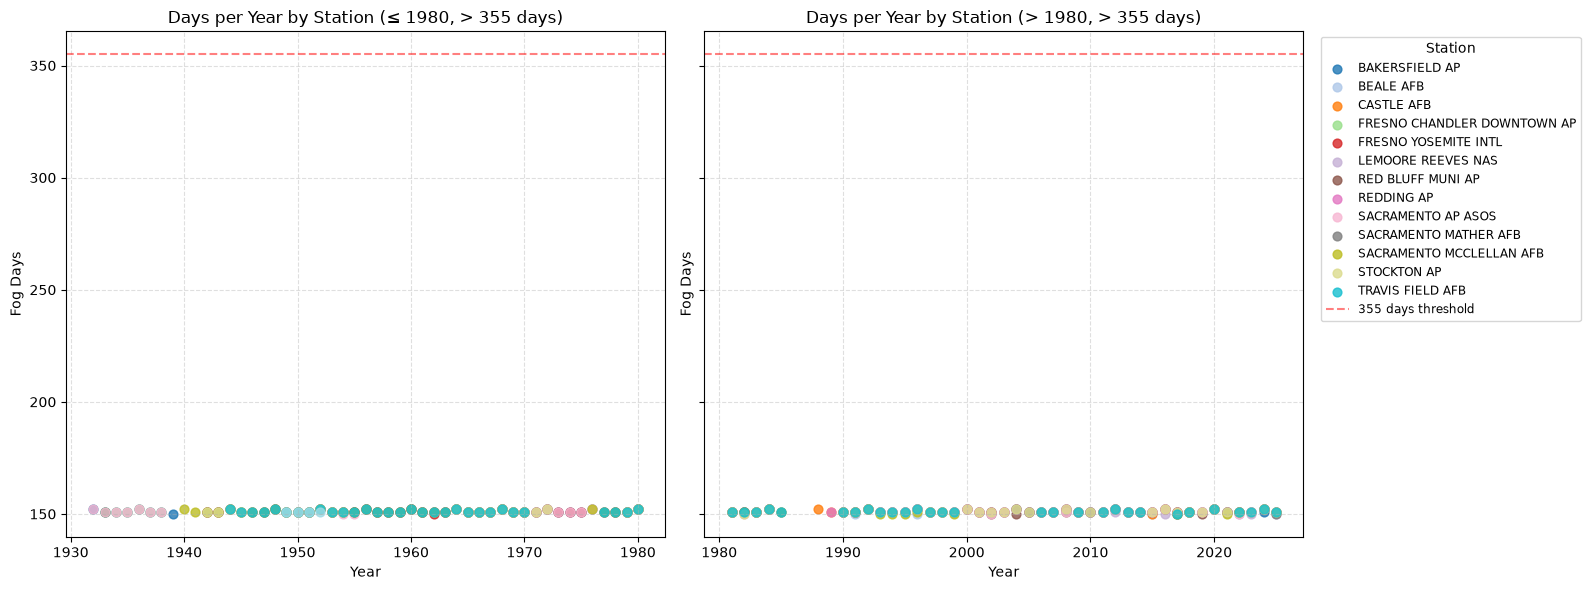

Stations with > 355 days: 16
['BAKERSFIELD AP', 'BEALE AFB', 'CASTLE AFB', 'FRESNO', 'FRESNO CHANDLER DOWNTOWN AP', 'FRESNO YOSEMITE INTL', 'GARDNER AAF', 'LEMOORE REEVES NAS', 'RED BLUFF MUNI AP', 'REDDING AP', 'SACRAMENTO AP ASOS', 'SACRAMENTO MATHER AFB', 'SACRAMENTO MCCLELLAN AFB', 'STOCKTON AP', 'TRAVIS FIELD AFB', 'WILLIAMS CAA AIRPORT']


In [43]:
# Remove stations with less than or only 355 days counted
fog_days_year_filtered = fog_days_year[fog_days_year['fog_days'] > 149]

# Get the filtered list of stations
filtered_plot_stations = [st for st in plot_stations if st in fog_days_year_filtered['STATION'].unique()]

# Create color map for filtered stations
colors_filtered = plt.cm.tab20(np.linspace(0, 1, len(filtered_plot_stations)))
color_map_filtered = dict(zip(filtered_plot_stations, colors_filtered))

# Filter fog data for pre-1970 stations with > 355 fog days
fog_pre1970_filtered = fog_days_year_filtered[fog_days_year_filtered['STATION'].isin(filtered_plot_stations)]

# Create the plot
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

for station in filtered_plot_stations:
    station_df = fog_pre1970_filtered[fog_pre1970_filtered['STATION'] == station].sort_values('year')
    pre_df = station_df[station_df['year'] <= 1980]
    post_df = station_df[station_df['year'] > 1980]

    if not pre_df.empty:
        axes[0].scatter(
            pre_df['year'],
            pre_df['fog_days'],
            s=40,
            color=color_map_filtered[station],
            alpha=0.8,
            label=station
        )

    if not post_df.empty:
        axes[1].scatter(
            post_df['year'],
            post_df['fog_days'],
            s=40,
            color=color_map_filtered[station],
            alpha=0.8,
            label=station
        )

axes[0].set_title('Days per Year by Station (≤ 1980, > 355 days)')
axes[1].set_title('Days per Year by Station (> 1980, > 355 days)')

for ax in axes:
    ax.set_xlabel('Year')
    ax.set_ylabel('Fog Days')
    ax.grid(True, linestyle='--', alpha=0.4)
    ax.axhline(y=355, color='red', linestyle='--', alpha=0.5, label='355 days threshold')

axes[1].legend(title='Station', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize='small')
plt.tight_layout()
plt.show()

print(f"Stations with > 355 days: {len(filtered_plot_stations)}")
print(filtered_plot_stations)

In [44]:
# Remove stations with 200 or fewer days counted
fog_days_year_no_outliers = fog_days_year[fog_days_year["fog_days"] > 149].copy()

# Get the valid station-year combinations for merging
valid_station_years = fog_days_year_no_outliers[["STATION", "year"]]
CV_fog_rows_no_outliers = CV_fog_rows.merge(valid_station_years, on=["STATION", "year"], how="inner")

# print to check
print("Station-years kept:", fog_days_year_no_outliers.shape[0])
print("CV_fog_rows_no_outliers:", CV_fog_rows_no_outliers.shape)

Station-years kept: 971
CV_fog_rows_no_outliers: (3888000, 14)


In [45]:
# Filter rows from the narrowed dataframe with HourlyVisibility < 1.000
low_vis_rows = CV_fog_rows_no_outliers[CV_fog_rows_no_outliers["HourlyVisibility"] < 0.403]
low_vis_rows_1km = CV_fog_rows_no_outliers[CV_fog_rows_no_outliers["HourlyVisibility"] < 1.000]

print("CV_fog_rows_no_outliers with HourlyVisibility < 0.403:", low_vis_rows.shape)
print("CV_fog_rows_no_outliers with HourlyVisibility < 1.000:", low_vis_rows_1km.shape)


CV_fog_rows_no_outliers with HourlyVisibility < 0.403: (163712, 14)
CV_fog_rows_no_outliers with HourlyVisibility < 1.000: (219523, 14)


In [46]:
# add a new dataframe to count the number of low visibility fog days per year per station
# with year, month, and day as unique identifiers to avoid double counting
low_vis_fog_days_year = (
    low_vis_rows
    .drop_duplicates(subset=['STATION', 'year', 'month', 'day'])
    .groupby(['STATION', 'year'], as_index=False)
    .size()
    .rename(columns={'size': 'fog_days'})
    .sort_values(['STATION', 'year'])
)

low_vis_fog_days_year_1km = (
    low_vis_rows_1km
    .drop_duplicates(subset=['STATION', 'year', 'month', 'day'])
    .groupby(['STATION', 'year'], as_index=False)
    .size()
    .rename(columns={'size': 'fog_days'})
    .sort_values(['STATION', 'year'])
)


In [47]:
# print the number of unique years for each station in low_vis_fog_days_year
station_year_counts = low_vis_fog_days_year.groupby("STATION")["year"].nunique()
stations_with_30_years = station_year_counts[station_year_counts >= 30].index

# filter low_vis_fog_days_year to only include stations with at least 30 years of data
low_vis_fog_days_year_filtered = low_vis_fog_days_year[
    low_vis_fog_days_year["STATION"].isin(stations_with_30_years)
].copy()

# print to check
print("Stations kept:", len(stations_with_30_years))
print("Filtered low_vis_fog_days_year rows:", low_vis_fog_days_year_filtered.shape)

# -----
# print the number of unique years for each station in low_vis_fog_days_year
station_year_counts_1km = low_vis_fog_days_year_1km.groupby("STATION")["year"].nunique()
stations_with_30_years_1km = station_year_counts_1km[station_year_counts_1km >= 30].index

# filter low_vis_fog_days_year to only include stations with at least 30 years of data
low_vis_fog_days_year_filtered_1km = low_vis_fog_days_year_1km[
    low_vis_fog_days_year_1km["STATION"].isin(stations_with_30_years_1km)
].copy()

# print to check
print("Stations kept:", len(stations_with_30_years_1km))
print("Filtered low_vis_fog_days_year_1km rows:", low_vis_fog_days_year_filtered_1km.shape)

Stations kept: 14
Filtered low_vis_fog_days_year rows: (783, 3)
Stations kept: 14
Filtered low_vis_fog_days_year_1km rows: (783, 3)


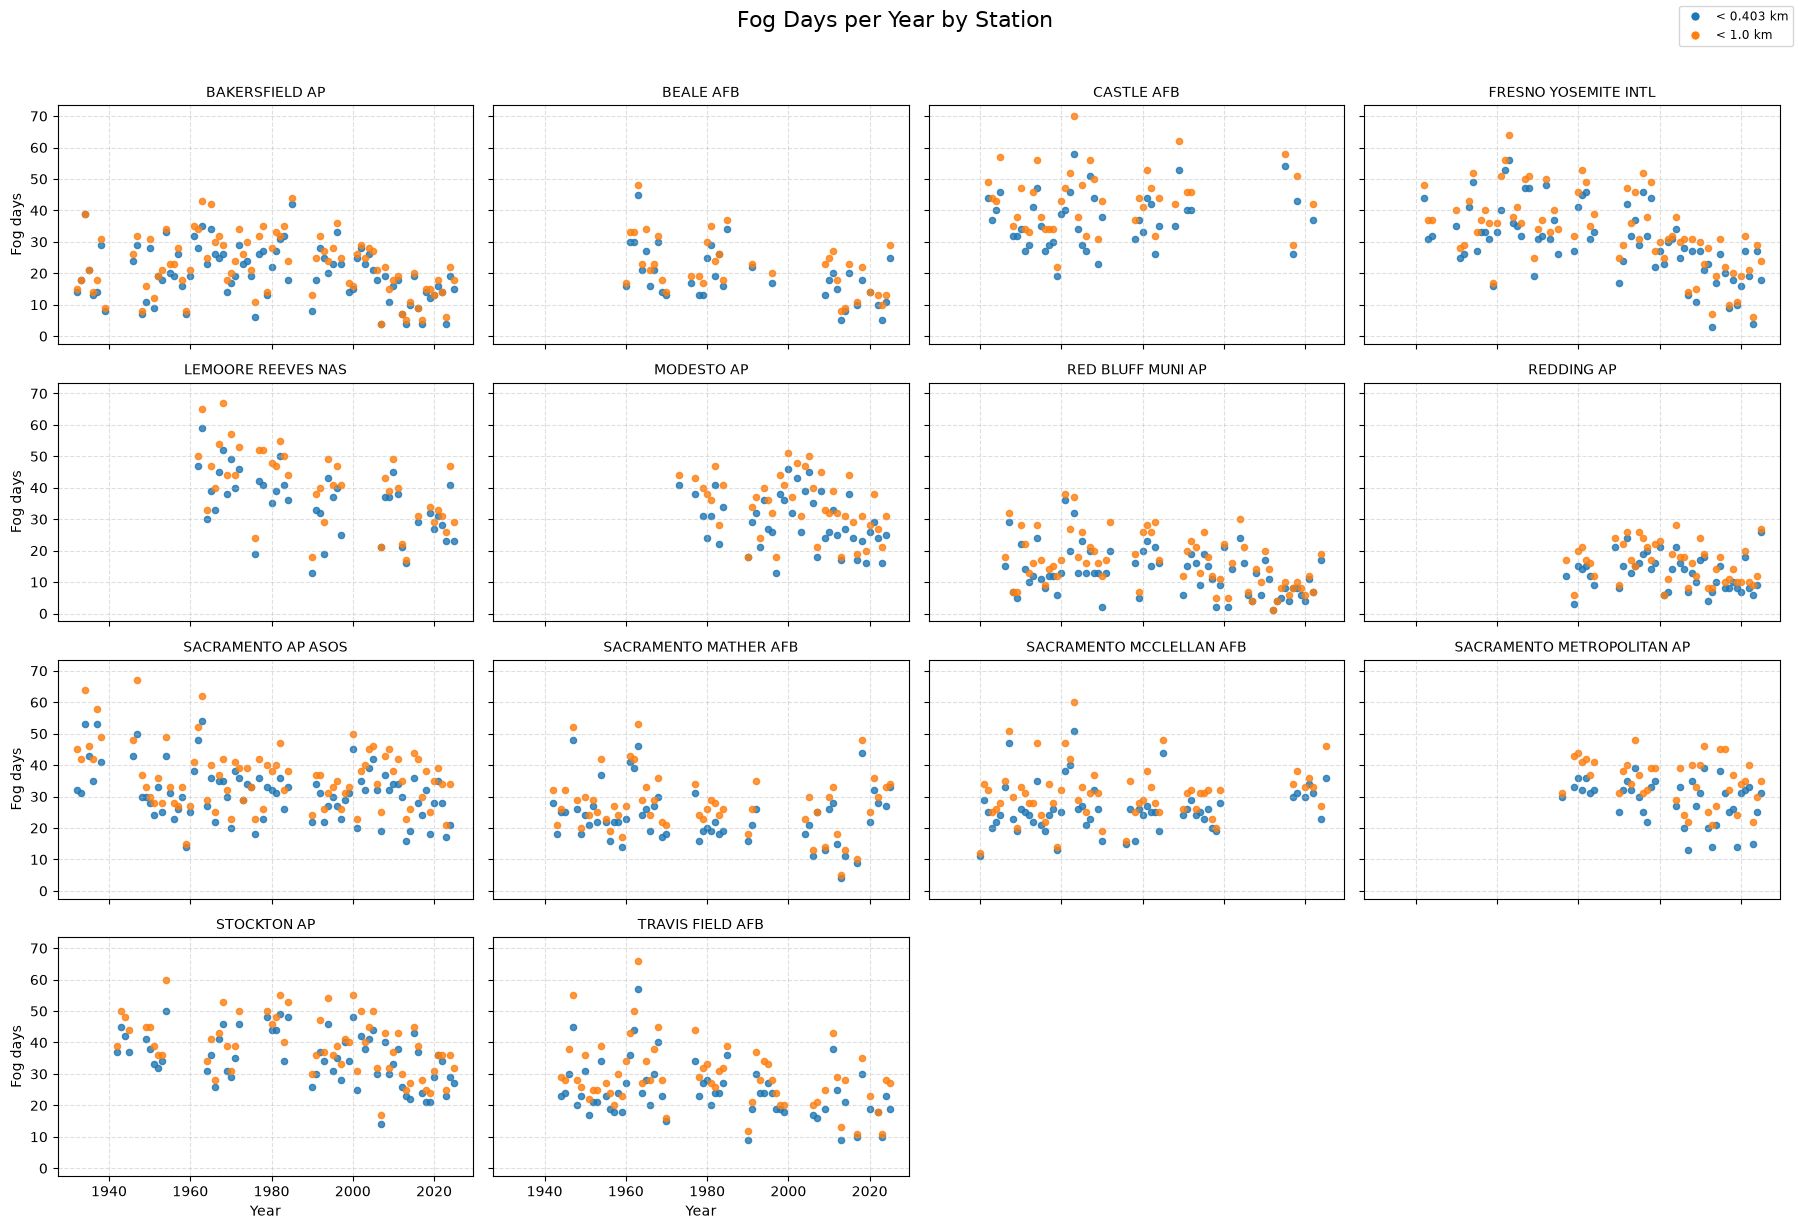

In [48]:
stations = sorted(
    set(low_vis_fog_days_year_filtered["STATION"])
    | set(low_vis_fog_days_year_filtered_1km["STATION"])
)

n_stations = len(stations)
ncols = 4
nrows = int(np.ceil(n_stations / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(18, nrows * 3), sharex=True, sharey=True)
axes = axes.flatten()

for idx, station in enumerate(stations):
    ax = axes[idx]
    df_h = low_vis_fog_days_year_filtered[
        low_vis_fog_days_year_filtered["STATION"] == station
    ].sort_values("year")
    df_1km = low_vis_fog_days_year_filtered_1km[
        low_vis_fog_days_year_filtered_1km["STATION"] == station
    ].sort_values("year")

    if not df_h.empty:
        ax.scatter(
            df_h["year"],
            df_h["fog_days"],
            s=20,
            alpha=0.8,
            color="tab:blue",
            label="< 0.403 km"
        )
    if not df_1km.empty:
        ax.scatter(
            df_1km["year"],
            df_1km["fog_days"],
            s=20,
            alpha=0.8,
            color="tab:orange",
            label="< 1.0 km"
        )

    ax.set_title(station, fontsize=10)
    ax.grid(True, linestyle="--", alpha=0.4)

    if idx % ncols == 0:
        ax.set_ylabel("Fog days")
    if idx >= (nrows - 1) * ncols:
        ax.set_xlabel("Year")

for ax in axes[n_stations:]:
    fig.delaxes(ax)

handles = [
    plt.Line2D([0], [0], marker="o", color="w", markerfacecolor="tab:blue", markersize=7),
    plt.Line2D([0], [0], marker="o", color="w", markerfacecolor="tab:orange", markersize=7),
]
fig.legend(handles, ["< 0.403 km", "< 1.0 km"], loc="upper right", fontsize="small")

fig.suptitle("Fog Days per Year by Station", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

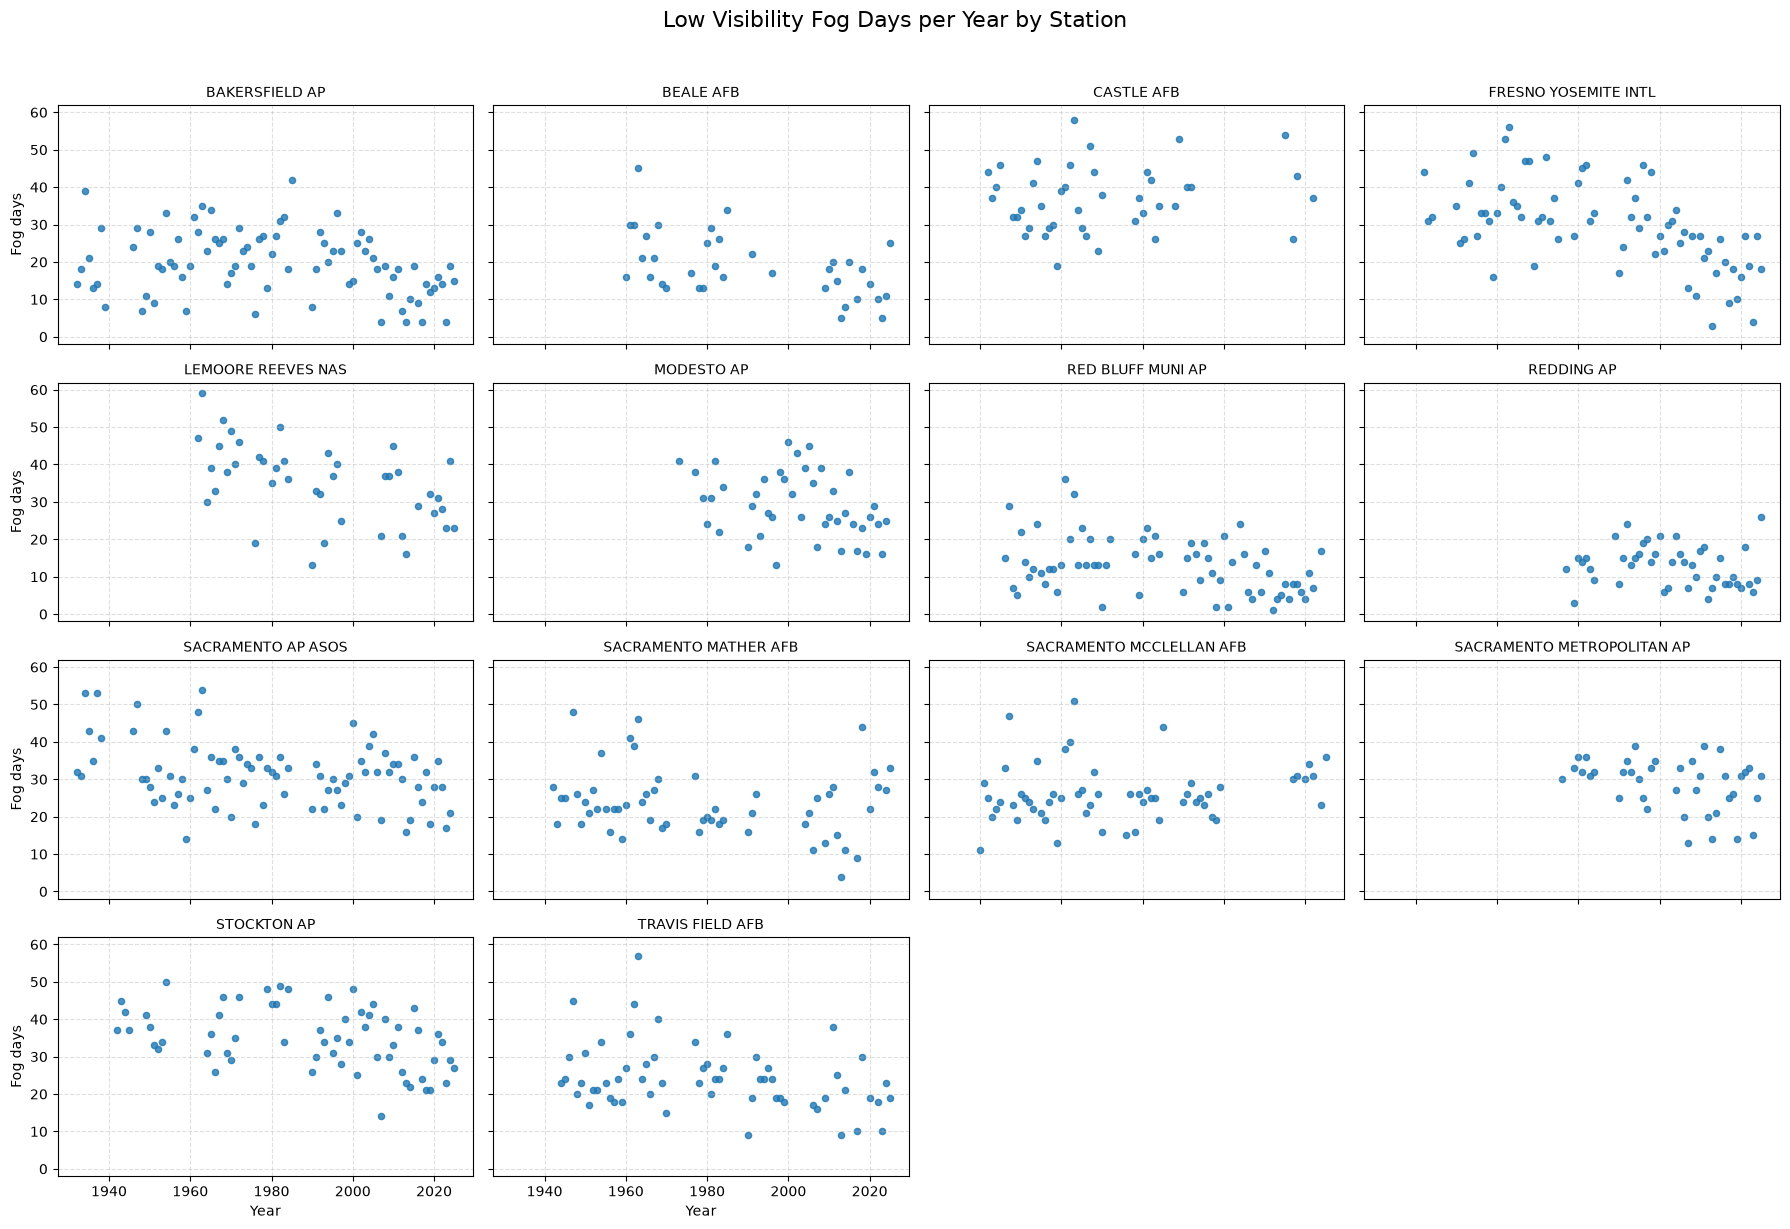

In [49]:
# plot the fog days per year for the filtered stations
stations = low_vis_fog_days_year_filtered['STATION'].unique()
n_stations = len(stations)
ncols = 4
nrows = int(np.ceil(n_stations / ncols))

# set up the plot:
fig, axes = plt.subplots(nrows, ncols, figsize=(18, nrows * 3), sharex=True, sharey=True)
axes = axes.flatten()

# plotting for individual stations:
for idx, station in enumerate(stations):
    ax = axes[idx]
    station_df = low_vis_fog_days_year_filtered[low_vis_fog_days_year_filtered['STATION'] == station]
    ax.scatter(station_df['year'], station_df['fog_days'], s=20, alpha=0.8)
    ax.set_title(station, fontsize=10)
    ax.grid(True, linestyle='--', alpha=0.4)

    if idx % ncols == 0:
        ax.set_ylabel('Fog days')
    if idx >= (nrows - 1) * ncols:
        ax.set_xlabel('Year')

for ax in axes[n_stations:]:
    fig.delaxes(ax)

fig.suptitle('Low Visibility Fog Days per Year by Station', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

In [50]:
# Filter for low visibility fog days after 1980
post1980_low_vis = low_vis_fog_days_year_filtered[low_vis_fog_days_year_filtered["year"] >= 1980].copy()

trend_stats_low_vis_post1980 = []

for station, station_df in post1980_low_vis.groupby("STATION"):
    station_df = station_df.sort_values("year")
    if len(station_df) < 3:
        continue

    model = smf.ols("fog_days ~ year", data=station_df).fit()

    trend_stats_low_vis_post1980.append({
        "STATION": station,
        "n_obs": len(station_df),
        "min_year": station_df["year"].min(),
        "max_year": station_df["year"].max(),
        "slope": model.params["year"],
        "intercept": model.params["Intercept"],
        "r_squared": model.rsquared,
        "p_value": model.pvalues["year"],
        "slope_se": model.bse["year"],
        "trend_significant": model.pvalues["year"] < 0.05,
    })

trend_stats_low_vis_post1980 = pd.DataFrame(trend_stats_low_vis_post1980).sort_values("p_value")

print("Post-1980 low-visibility fog-day trend statistics by station:")
print(trend_stats_low_vis_post1980[
    ["STATION", "n_obs", "min_year", "max_year", "slope", "slope_se", "p_value", "r_squared", "trend_significant"]
].head(20))

significant_low_vis_post1980 = trend_stats_low_vis_post1980[trend_stats_low_vis_post1980["trend_significant"]]
print(f"\nStations with significant post-1980 low-visibility fog-day trends: {len(significant_low_vis_post1980)}")
print(significant_low_vis_post1980[
    ["STATION", "n_obs", "slope", "p_value", "r_squared"]
])

annual_low_vis_post1980 = (
    post1980_low_vis
    .groupby("year", as_index=False)["fog_days"]
    .sum()
)

model_annual_low_vis_post1980 = smf.ols("fog_days ~ year", data=annual_low_vis_post1980).fit()

print("\nAnnual aggregated post-1980 low-visibility fog-day trend summary:")
print(model_annual_low_vis_post1980.summary())

Post-1980 low-visibility fog-day trend statistics by station:
                       STATION  n_obs  min_year  max_year     slope  slope_se  \
3         FRESNO YOSEMITE INTL     41      1980      2025 -0.586052  0.097954   
0               BAKERSFIELD AP     41      1980      2025 -0.413335  0.081580   
6            RED BLUFF MUNI AP     38      1980      2024 -0.269389  0.072958   
12                 STOCKTON AP     41      1980      2025 -0.337606  0.092090   
1                    BEALE AFB     22      1980      2025 -0.299502  0.080012   
11  SACRAMENTO METROPOLITAN AP     37      1980      2025 -0.186211  0.083033   
13            TRAVIS FIELD AFB     30      1980      2025 -0.157279  0.087486   
7                   REDDING AP     42      1980      2025 -0.110757  0.062902   
4           LEMOORE REEVES NAS     28      1980      2025 -0.191033  0.115217   
10    SACRAMENTO MCCLELLAN AFB     23      1980      2025  0.124195  0.075380   
5                   MODESTO AP     40      1980

In [51]:
# Filter for low visibility fog days after 1980
post1980_low_vis_1km = low_vis_fog_days_year_filtered_1km[low_vis_fog_days_year_filtered_1km["year"] >= 1980].copy()

trend_stats_low_vis_post1980_1km = []

for station, station_df in post1980_low_vis_1km.groupby("STATION"):
    station_df = station_df.sort_values("year")
    if len(station_df) < 3:
        continue

    model = smf.ols("fog_days ~ year", data=station_df).fit()

    trend_stats_low_vis_post1980_1km.append({
        "STATION": station,
        "n_obs": len(station_df),
        "min_year": station_df["year"].min(),
        "max_year": station_df["year"].max(),
        "slope": model.params["year"],
        "intercept": model.params["Intercept"],
        "r_squared": model.rsquared,
        "p_value": model.pvalues["year"],
        "slope_se": model.bse["year"],
        "trend_significant": model.pvalues["year"] < 0.05,
    })

trend_stats_low_vis_post1980_1km = pd.DataFrame(trend_stats_low_vis_post1980_1km).sort_values("p_value")

print("Post-1980 low-visibility fog-day trend statistics by station:")
print(trend_stats_low_vis_post1980_1km[
    ["STATION", "n_obs", "min_year", "max_year", "slope", "slope_se", "p_value", "r_squared", "trend_significant"]
].head(20))

significant_low_vis_post1980_1km = trend_stats_low_vis_post1980_1km[trend_stats_low_vis_post1980_1km["trend_significant"]]
print(f"\nStations with significant post-1980 low-visibility fog-day trends: {len(significant_low_vis_post1980_1km)}")
print(significant_low_vis_post1980_1km[
    ["STATION", "n_obs", "slope", "p_value", "r_squared"]
])

annual_low_vis_post1980_1km = (
    post1980_low_vis_1km
    .groupby("year", as_index=False)["fog_days"]
    .sum()
)

model_annual_low_vis_post1980_1km = smf.ols("fog_days ~ year", data=annual_low_vis_post1980_1km).fit()

print("\nAnnual aggregated post-1980 low-visibility fog-day trend summary:")
print(model_annual_low_vis_post1980_1km.summary())

Post-1980 low-visibility fog-day trend statistics by station:
                       STATION  n_obs  min_year  max_year     slope  slope_se  \
3         FRESNO YOSEMITE INTL     41      1980      2025 -0.660703  0.104010   
0               BAKERSFIELD AP     41      1980      2025 -0.491368  0.081271   
6            RED BLUFF MUNI AP     38      1980      2024 -0.396814  0.082924   
12                 STOCKTON AP     41      1980      2025 -0.395938  0.096451   
1                    BEALE AFB     22      1980      2025 -0.303194  0.089988   
4           LEMOORE REEVES NAS     28      1980      2025 -0.342838  0.120245   
11  SACRAMENTO METROPOLITAN AP     37      1980      2025 -0.192138  0.084339   
7                   REDDING AP     42      1980      2025 -0.152769  0.069828   
13            TRAVIS FIELD AFB     30      1980      2025 -0.181122  0.101168   
5                   MODESTO AP     40      1980      2024 -0.204038  0.115697   
10    SACRAMENTO MCCLELLAN AFB     23      1980

In [52]:
# make a list of stations with significant trends for fog days after 1980
stations_significant_low_vis_post1980 = significant_low_vis_post1980.loc[
    significant_low_vis_post1980["trend_significant"], "STATION"
].tolist()

print("Significant post-1980 low-visibility fog-day trend stations:")
print(stations_significant_low_vis_post1980)

Significant post-1980 low-visibility fog-day trend stations:
['FRESNO YOSEMITE INTL', 'BAKERSFIELD AP', 'RED BLUFF MUNI AP', 'STOCKTON AP', 'BEALE AFB', 'SACRAMENTO METROPOLITAN AP']


In [53]:
# make a list of stations with significant trends for fog days after 1980
stations_significant_low_vis_post1980_1km = significant_low_vis_post1980_1km.loc[
    significant_low_vis_post1980_1km["trend_significant"], "STATION"
].tolist()

print("Significant post-1980 low-visibility (<1km) fog-day trend stations:")
print(stations_significant_low_vis_post1980_1km)

Significant post-1980 low-visibility (<1km) fog-day trend stations:
['FRESNO YOSEMITE INTL', 'BAKERSFIELD AP', 'RED BLUFF MUNI AP', 'STOCKTON AP', 'BEALE AFB', 'LEMOORE REEVES NAS', 'SACRAMENTO METROPOLITAN AP', 'REDDING AP']


In [54]:
stations = stations_significant_low_vis_post1980

post1980_h = low_vis_fog_days_year_filtered[
    low_vis_fog_days_year_filtered["year"] >= 1980
]
post1980_1km = low_vis_fog_days_year_filtered_1km[
    low_vis_fog_days_year_filtered_1km["year"] >= 1980
]


In [55]:
# Plot post-1980 scatterplots per station showing <0.403 km and <1.0 km points.
# If only one threshold has a confirmed trend for a station, plot only that threshold.
stations_h_sig = set(stations_significant_low_vis_post1980)      # <0.403 km significant
stations_1km_sig = set(stations_significant_low_vis_post1980_1km)  # <1.0 km significant


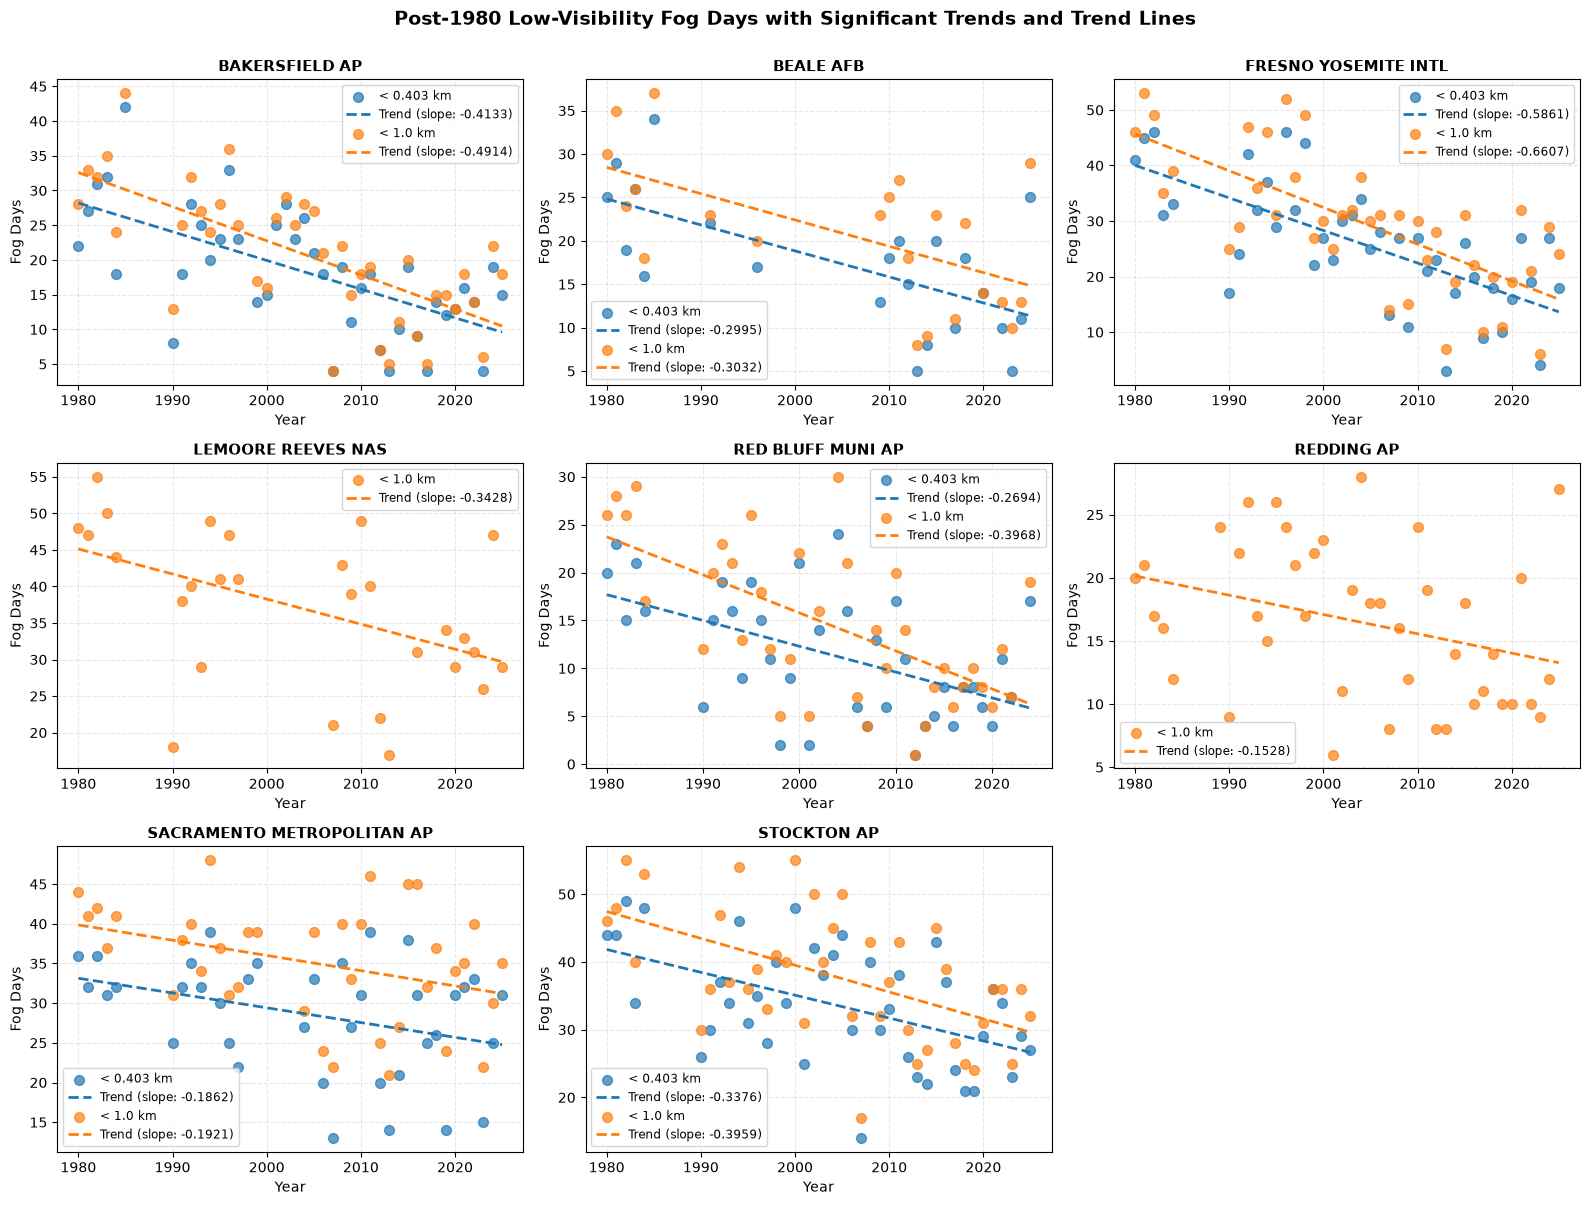

In [56]:
# Create scatterplots with trend lines for stations with significant trends
stations_to_plot = sorted(stations_h_sig | stations_1km_sig)
n_stations = len(stations_to_plot)
ncols = 3
nrows = int(np.ceil(n_stations / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(16, nrows * 4))
axes = axes.flatten()

for idx, station in enumerate(stations_to_plot):
    ax = axes[idx]
    sig_h = station in stations_h_sig
    sig_1km = station in stations_1km_sig
    
    df_h = post1980_h[post1980_h["STATION"] == station].sort_values("year")
    df_1km = post1980_1km[post1980_1km["STATION"] == station].sort_values("year")
    
    # Plot data and trend lines for significant thresholds
    if sig_h and not df_h.empty:
        ax.scatter(df_h["year"], df_h["fog_days"], s=50, color="tab:blue", alpha=0.7, label="< 0.403 km")
        model_h = smf.ols("fog_days ~ year", data=df_h).fit()
        slope_h = model_h.params["year"]
        trend_line_h = model_h.predict(df_h)
        ax.plot(df_h["year"], trend_line_h, color="tab:blue", linewidth=2, linestyle="--", 
                label=f"Trend (slope: {slope_h:.4f})")
    
    if sig_1km and not df_1km.empty:
        ax.scatter(df_1km["year"], df_1km["fog_days"], s=50, color="tab:orange", alpha=0.7, label="< 1.0 km")
        model_1km = smf.ols("fog_days ~ year", data=df_1km).fit()
        slope_1km = model_1km.params["year"]
        trend_line_1km = model_1km.predict(df_1km)
        ax.plot(df_1km["year"], trend_line_1km, color="tab:orange", linewidth=2, linestyle="--",
                label=f"Trend (slope: {slope_1km:.4f})")
    
    ax.set_title(station, fontsize=11, fontweight="bold")
    ax.set_xlabel("Year")
    ax.set_ylabel("Fog Days")
    ax.grid(True, linestyle="--", alpha=0.3)
    ax.legend(fontsize="small", loc="best")

# Remove unused axes
for ax in axes[n_stations:]:
    fig.delaxes(ax)

fig.suptitle("Post-1980 Low-Visibility Fog Days with Significant Trends and Trend Lines", 
             fontsize=14, fontweight="bold", y=1.00)
plt.tight_layout()
plt.show()

In [136]:
# read in the CSV of counted fog rows for the Central Valley stations
path1 = 'E:/Central Valley Fog/fog_rows_cleaned1.csv'
if os.path.exists(path1):
    CVfog_rows = pd.read_csv(path1, low_memory = False)
else:
    path = '/Volumes/disk1/Central Valley Fog/fog_rows_cleaned1.csv'
    CVfog_rows = pd.read_csv(path, low_memory = False)



print(CVfog_rows)

       STATION_ID  LATITUDE  LONGITUDE                 DATE  \
0     USW00053119  36.31889 -119.62889  2006-01-31T23:59:00   
1     USW00053119  36.31889 -119.62889  2006-02-28T23:59:00   
2     USW00053119  36.31889 -119.62889  2006-03-31T23:59:00   
3     USW00053119  36.31889 -119.62889  2006-04-30T23:59:00   
4     USW00053119  36.31889 -119.62889  2006-10-31T23:59:00   
...           ...       ...        ...                  ...   
2480  USW00024257  40.51750 -122.29860  2024-11-30T23:59:00   
2481  USW00024257  40.51750 -122.29860  2025-02-28T23:59:00   
2482  USW00024257  40.51750 -122.29860  2025-03-31T23:59:00   
2483  USW00024257  40.51750 -122.29860  2026-01-31T23:59:00   
2484  USW00024257  40.51750 -122.29860  2026-02-28T23:59:00   

      HourlyPrecipitation  HourlyVisibility  MonthlyNumberDaysWithHeavyFog  \
0                     NaN               NaN                           19.0   
1                     NaN               NaN                           16.0   
2        

In [137]:
# Make a yearly counted-fog-days dataframe from CVfog_rows
CVfog_yearly = (
    CVfog_rows.assign(year=pd.to_datetime(CVfog_rows["DATE"]).dt.year)
    .groupby(["STATION", "year"], as_index=False)["MonthlyNumberDaysWithHeavyFog"]
    .sum()
    .rename(columns={"MonthlyNumberDaysWithHeavyFog": "fog_days"})
    .sort_values(["STATION", "year"])
    .reset_index(drop=True)
)

print(CVfog_yearly.head())
print(CVfog_yearly.shape)

          STATION  year  fog_days
0  BAKERSFIELD AP  1965      37.0
1  BAKERSFIELD AP  1966      27.0
2  BAKERSFIELD AP  1967      28.0
3  BAKERSFIELD AP  1968      27.0
4  BAKERSFIELD AP  1969      13.0
(570, 3)


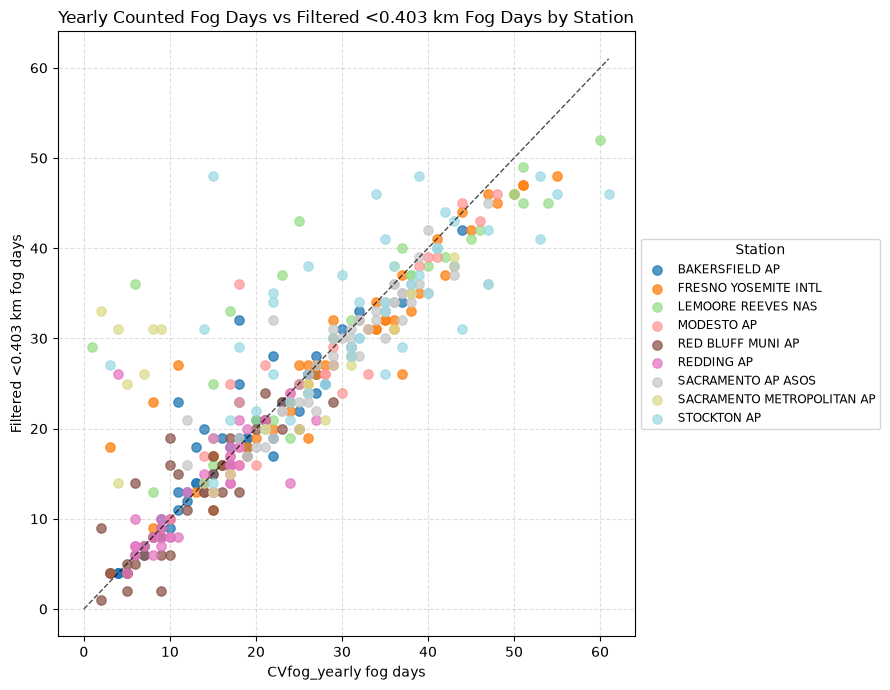

In [138]:
# Compare yearly counted fog days from CVfog_yearly
# to yearly low-visibility (<0.403 km) fog days from low_vis_fog_days_year_filtered
comparison_plot = (
    CVfog_yearly
    .rename(columns={"fog_days": "counted_fog_days"})
    .merge(
        low_vis_fog_days_year_filtered.rename(columns={"fog_days": "low_vis_0_403km"}),
        on=["STATION", "year"],
        how="inner"
    )
    .sort_values(["STATION", "year"])
    .reset_index(drop=True)
)

stations = sorted(comparison_plot["STATION"].unique())
station_colors = dict(zip(stations, plt.cm.tab20(np.linspace(0, 1, len(stations)))))

fig, ax = plt.subplots(figsize=(9, 7))

for station in stations:
    station_df = comparison_plot[comparison_plot["STATION"] == station]
    ax.scatter(
        station_df["counted_fog_days"],
        station_df["low_vis_0_403km"],
        s=45,
        color=station_colors[station],
        alpha=0.75,
        label=station
    )

max_val = max(
    comparison_plot["counted_fog_days"].max(),
    comparison_plot["low_vis_0_403km"].max()
)
ax.plot([0, max_val], [0, max_val], color="black", linestyle="--", linewidth=1, alpha=0.7)

ax.set_xlabel("CVfog_yearly fog days")
ax.set_ylabel("Filtered <0.403 km fog days")
ax.set_title("Yearly Counted Fog Days vs Filtered <0.403 km Fog Days by Station")
ax.grid(True, linestyle="--", alpha=0.4)
ax.legend(loc="center left", bbox_to_anchor=(1.0, 0.5), fontsize="small", title="Station")

plt.tight_layout()
plt.show()

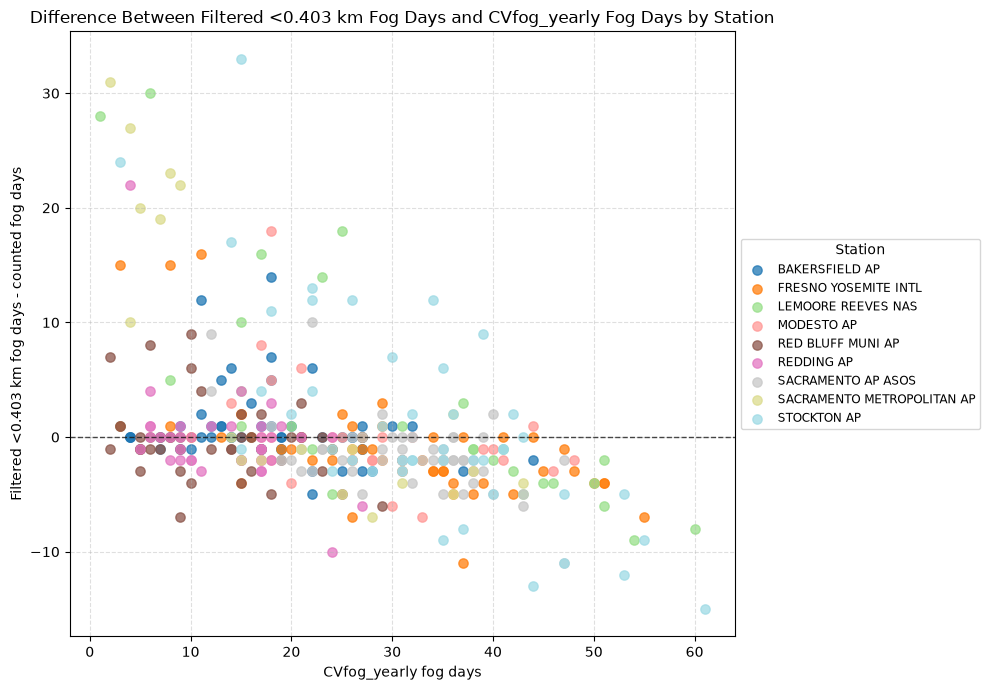

In [139]:
# Scatterplot of the difference between filtered <0.403 km visibility fog days
# and yearly counted fog days, with one color per station
comparison_scatter = (
    comparison_plot.assign(
        diff_lowvis_minus_counted=lambda d: d["low_vis_0_403km"] - d["counted_fog_days"]
    )
    .sort_values(["STATION", "year"])
    .reset_index(drop=True)
)

stations = sorted(comparison_scatter["STATION"].unique())
station_colors = dict(zip(stations, plt.cm.tab20(np.linspace(0, 1, len(stations)))))

fig, ax = plt.subplots(figsize=(10, 7))

for station in stations:
    station_df = comparison_scatter[comparison_scatter["STATION"] == station]
    ax.scatter(
        station_df["counted_fog_days"],
        station_df["diff_lowvis_minus_counted"],
        s=45,
        color=station_colors[station],
        alpha=0.75,
        label=station
    )

ax.axhline(0, color="black", linestyle="--", linewidth=1, alpha=0.7)
ax.set_xlabel("CVfog_yearly fog days")
ax.set_ylabel("Filtered <0.403 km fog days - counted fog days")
ax.set_title("Difference Between Filtered <0.403 km Fog Days and CVfog_yearly Fog Days by Station")
ax.grid(True, linestyle="--", alpha=0.4)
ax.legend(loc="center left", bbox_to_anchor=(1.0, 0.5), fontsize="small", title="Station")

plt.tight_layout()
plt.show()

In [61]:
# Scatterplot of the yearly difference between counted fog days and filtered <0.403 km fog days
# with one color per station and year on the x-axis

station_year_difference = (
    station_year_comparison.assign(
        diff_counted_minus_lowvis=lambda d: d["counted_fog_days"] - d["low_vis_0_403km"]
    )
    .sort_values(["STATION", "year"])
    .reset_index(drop=True)
)

stations = sorted(station_year_difference["STATION"].unique())
station_colors = dict(zip(stations, plt.cm.tab20(np.linspace(0, 1, len(stations)))))

fig, ax = plt.subplots(figsize=(12, 7))

for station in stations:
    station_df = station_year_difference[station_year_difference["STATION"] == station]
    ax.scatter(
        station_df["year"],
        station_df["diff_counted_minus_lowvis"],
        s=45,
        color=station_colors[station],
        alpha=0.75,
        label=station
    )

ax.axhline(0, color="black", linestyle="--", linewidth=1, alpha=0.7)
ax.set_xlabel("Year")
ax.set_ylabel("Counted fog days - filtered <0.403 km fog days")
ax.set_title("Yearly Difference Between Counted Fog Days and Filtered <0.403 km Fog Days by Station")
ax.grid(True, linestyle="--", alpha=0.4)
ax.legend(loc="center left", bbox_to_anchor=(1.0, 0.5), fontsize="small", title="Station")

plt.tight_layout()
plt.show()

NameError: name 'station_year_comparison' is not defined

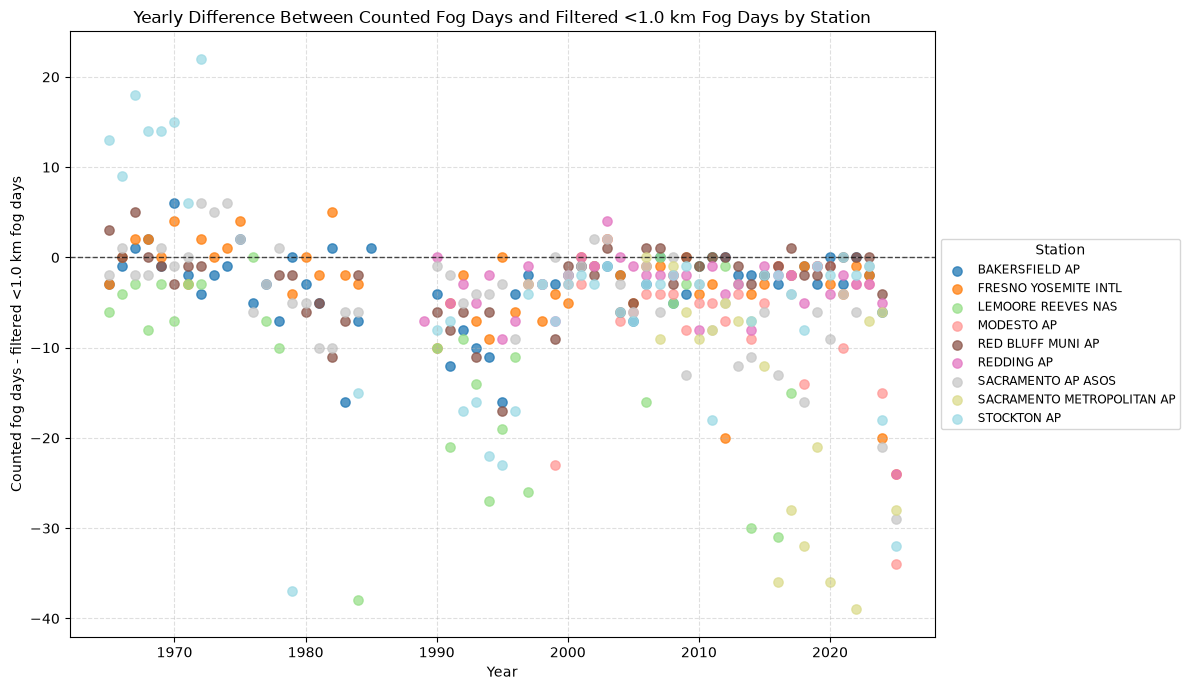

In [65]:
# Scatterplot of yearly difference between counted fog days and filtered <1.0 km visibility fog days
station_year_difference_1km = (
    station_year_comparison_1km.assign(
        diff_counted_minus_lowvis=lambda d: d["counted_fog_days"] - d["low_vis_1km"]
    )
    .sort_values(["STATION", "year"])
    .reset_index(drop=True)
)

stations = sorted(station_year_difference_1km["STATION"].unique())
station_colors = dict(zip(stations, plt.cm.tab20(np.linspace(0, 1, len(stations)))))

fig, ax = plt.subplots(figsize=(12, 7))

for station in stations:
    station_df = station_year_difference_1km[station_year_difference_1km["STATION"] == station]
    ax.scatter(
        station_df["year"],
        station_df["diff_counted_minus_lowvis"],
        s=45,
        color=station_colors[station],
        alpha=0.75,
        label=station
    )

ax.axhline(0, color="black", linestyle="--", linewidth=1, alpha=0.7)
ax.set_xlabel("Year")
ax.set_ylabel("Counted fog days - filtered <1.0 km fog days")
ax.set_title("Yearly Difference Between Counted Fog Days and Filtered <1.0 km Fog Days by Station")
ax.grid(True, linestyle="--", alpha=0.4)
ax.legend(loc="center left", bbox_to_anchor=(1.0, 0.5), fontsize="small", title="Station")

plt.tight_layout()
plt.show()

In [29]:
# Compare yearly counted heavy-fog days from CVfog_yearly
# against yearly low-visibility (<0.403 km) fog days from low_vis_fog_days_year_filtered

comparison_df = (
    CVfog_yearly
    .rename(columns={"fog_days": "heavy_fog_days"})
    .merge(
        low_vis_fog_days_year_filtered.rename(columns={"fog_days": "low_vis_fog_days"}),
        on=["STATION", "year"],
        how="inner"
    )
    .assign(
        diff_heavy_minus_lowvis=lambda d: d["heavy_fog_days"] - d["low_vis_fog_days"]
    )
    .sort_values(["STATION", "year"])
    .reset_index(drop=True)
)

print("Merged comparison table:")
print(comparison_df.head(20))
print(f"\nRows in comparison_df: {comparison_df.shape[0]}")

# Optional station-level summary
station_comparison_summary = (
    comparison_df
    .groupby("STATION", as_index=False)
    .agg(
        n_years=("year", "count"),
        mean_heavy_fog_days=("heavy_fog_days", "mean"),
        mean_low_vis_fog_days=("low_vis_fog_days", "mean"),
        mean_diff_heavy_minus_lowvis=("diff_heavy_minus_lowvis", "mean")
    )
    .sort_values("STATION")
)

print("\nStation-level summary:")
print(station_comparison_summary)

Merged comparison table:
           STATION  year  heavy_fog_days  low_vis_fog_days  \
0   BAKERSFIELD AP  1965            37.0                29   
1   BAKERSFIELD AP  1966            27.0                20   
2   BAKERSFIELD AP  1967            28.0                16   
3   BAKERSFIELD AP  1968            27.0                17   
4   BAKERSFIELD AP  1969            13.0                10   
5   BAKERSFIELD AP  1970            22.0                13   
6   BAKERSFIELD AP  1971            22.0                17   
7   BAKERSFIELD AP  1972            31.0                23   
8   BAKERSFIELD AP  1973            18.0                14   
9   BAKERSFIELD AP  1974            27.0                22   
10  BAKERSFIELD AP  1975            19.0                15   
11  BAKERSFIELD AP  1976             7.0                 5   
12  BAKERSFIELD AP  1977            26.0                19   
13  BAKERSFIELD AP  1978            27.0                25   
14  BAKERSFIELD AP  1979            12.0     

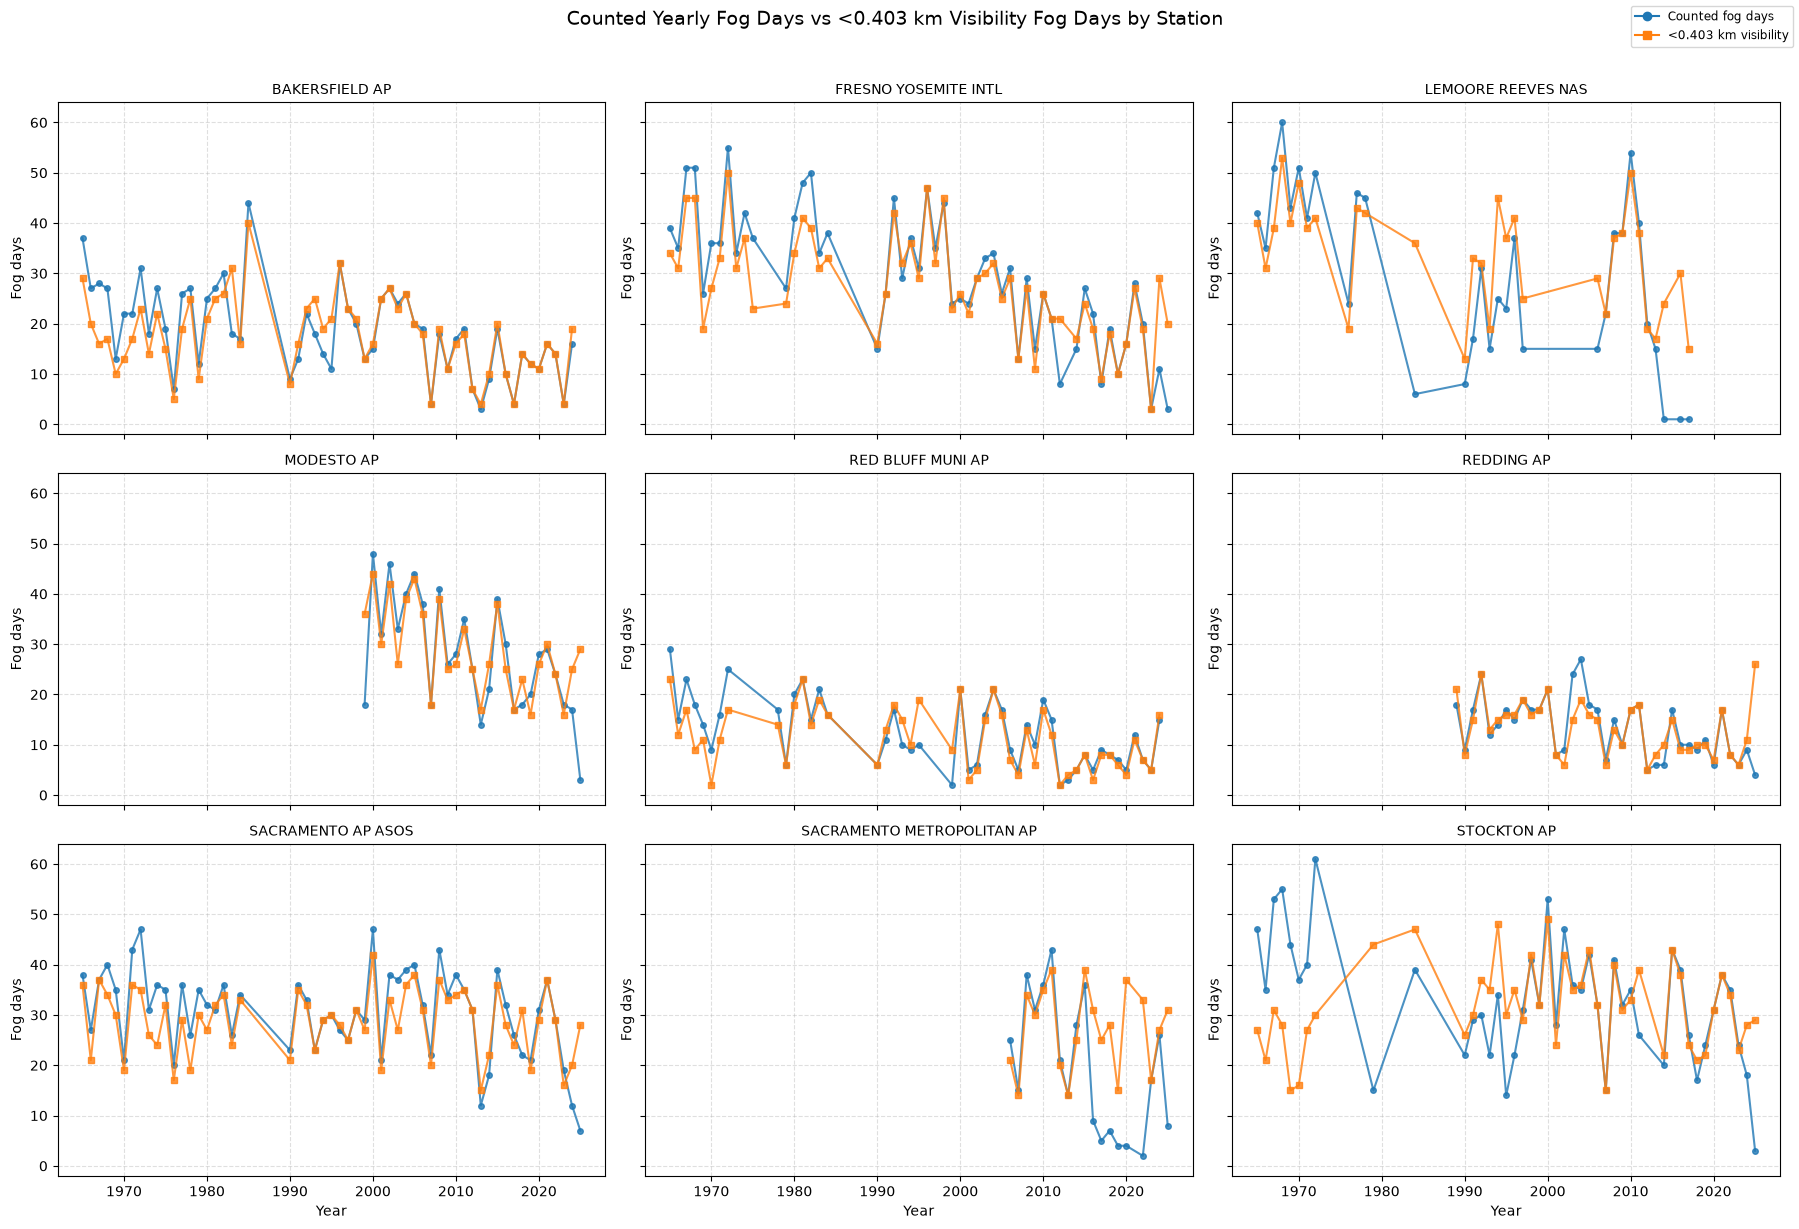

In [32]:
# Merge counted yearly fog days with the <0.403 km visibility series
station_year_comparison = (
    CVfog_yearly
    .rename(columns={"fog_days": "counted_fog_days"})
    .merge(
        low_vis_fog_days_year_filtered.rename(columns={"fog_days": "low_vis_0_403km"}),
        on=["STATION", "year"],
        how="inner"
    )
    .sort_values(["STATION", "year"])
    .reset_index(drop=True)
)

stations = sorted(station_year_comparison["STATION"].unique())
n_stations = len(stations)
ncols = 3
nrows = int(np.ceil(n_stations / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(18, nrows * 4), sharex=True, sharey=True)
axes = axes.flatten()

for idx, station in enumerate(stations):
    ax = axes[idx]
    station_df = station_year_comparison[station_year_comparison["STATION"] == station].sort_values("year")

    ax.plot(
        station_df["year"],
        station_df["counted_fog_days"],
        color="tab:blue",
        marker="o",
        markersize=4,
        linewidth=1.5,
        alpha=0.8,
        label="Counted fog days"
    )
    ax.plot(
        station_df["year"],
        station_df["low_vis_0_403km"],
        color="tab:orange",
        marker="s",
        markersize=4,
        linewidth=1.5,
        alpha=0.8,
        label="<0.403 km visibility"
    )

    ax.set_title(station, fontsize=10)
    ax.grid(True, linestyle="--", alpha=0.4)
    ax.set_ylabel("Fog days")

    if idx % ncols == 0:
        ax.set_ylabel("Fog days")
    if idx >= (nrows - 1) * ncols:
        ax.set_xlabel("Year")

for ax in axes[n_stations:]:
    fig.delaxes(ax)

handles = [
    plt.Line2D([0], [0], color="tab:blue", marker="o", linewidth=1.5, markersize=6, label="Counted fog days"),
    plt.Line2D([0], [0], color="tab:orange", marker="s", linewidth=1.5, markersize=6, label="<0.403 km visibility"),
]
fig.legend(handles=handles, loc="upper right", fontsize="small")

fig.suptitle("Counted Yearly Fog Days vs <0.403 km Visibility Fog Days by Station", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

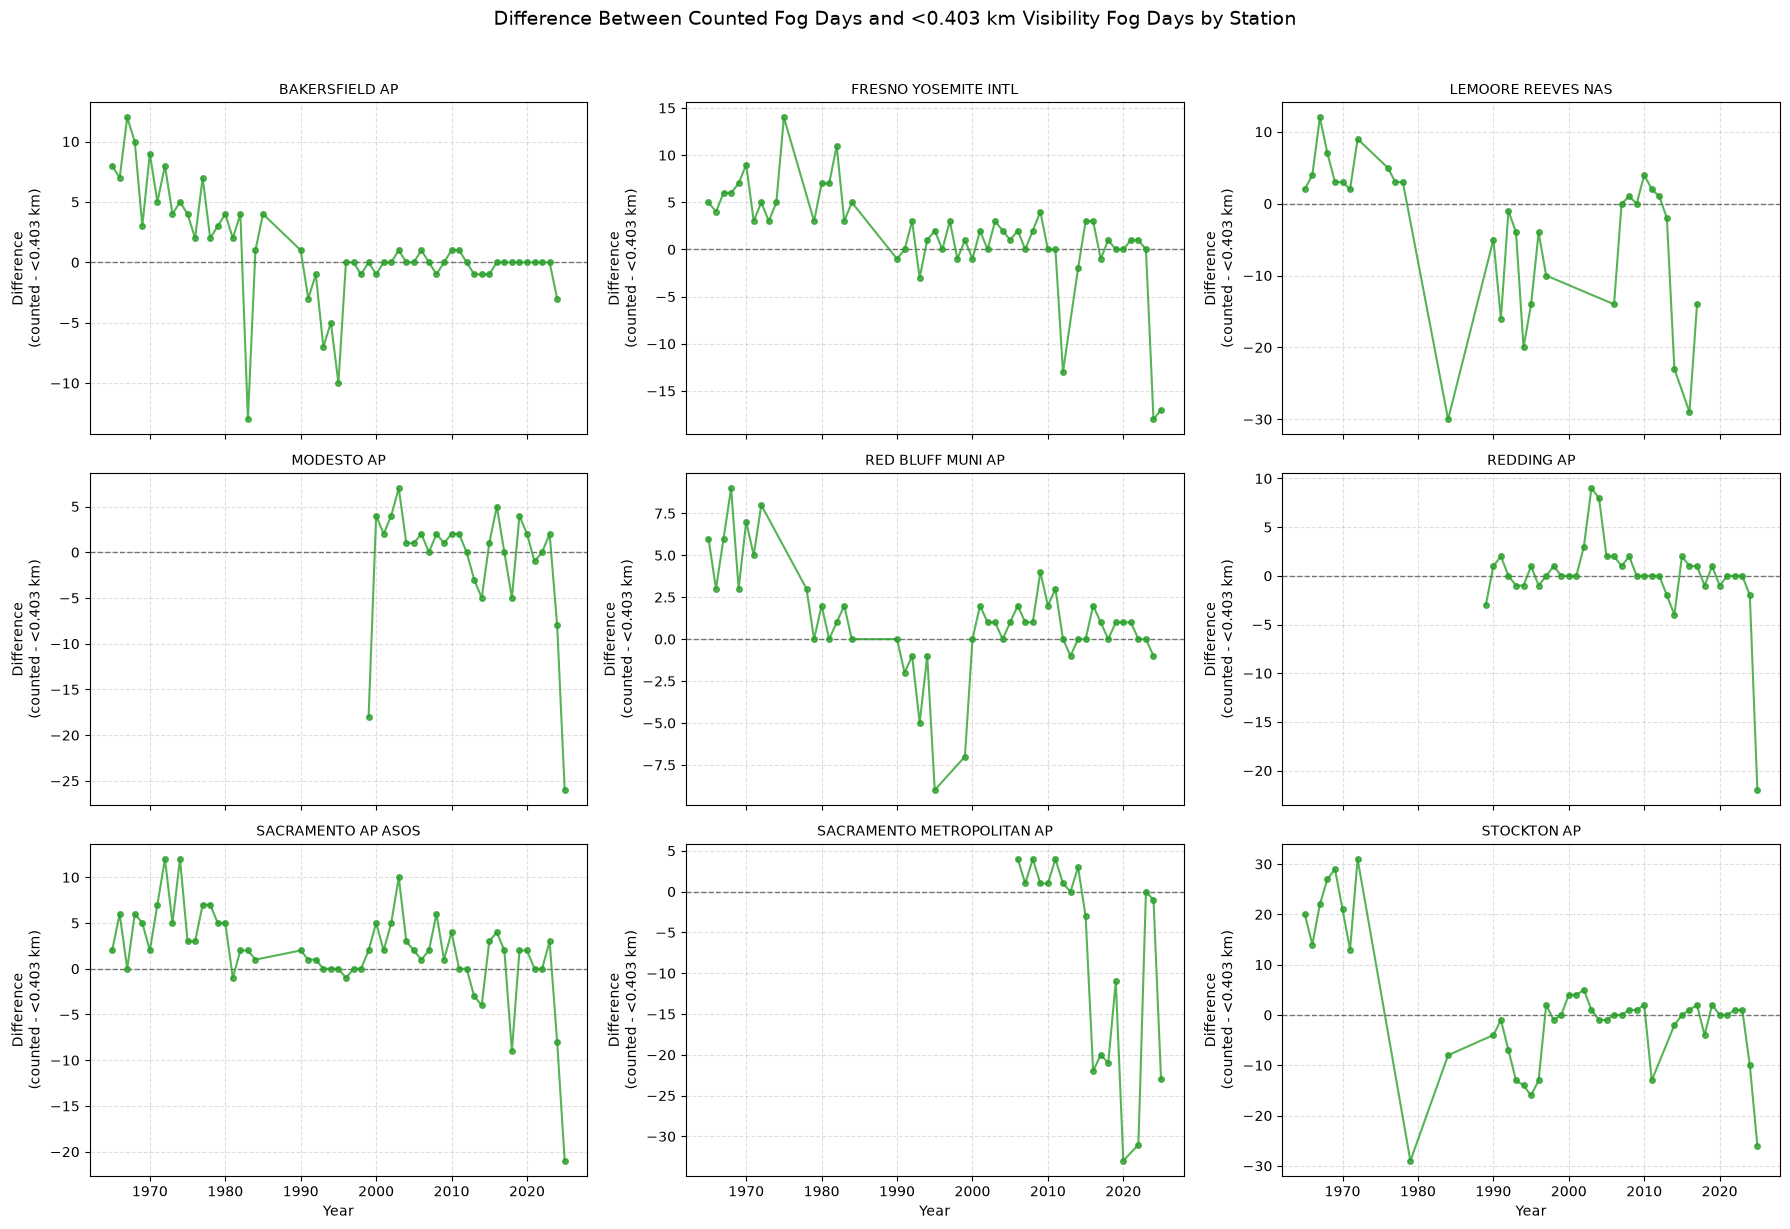

In [33]:
# Plot the difference between counted yearly fog days and <0.403 km visibility fog days by station
station_year_difference = (
    station_year_comparison.assign(
        diff_counted_minus_lowvis=lambda d: d["counted_fog_days"] - d["low_vis_0_403km"]
    )
    .sort_values(["STATION", "year"])
    .reset_index(drop=True)
)

stations = sorted(station_year_difference["STATION"].unique())
n_stations = len(stations)
ncols = 3
nrows = int(np.ceil(n_stations / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(18, nrows * 4), sharex=True)
axes = axes.flatten()

for idx, station in enumerate(stations):
    ax = axes[idx]
    station_df = station_year_difference[station_year_difference["STATION"] == station].sort_values("year")

    ax.axhline(0, color="black", linestyle="--", linewidth=1, alpha=0.5)
    ax.plot(
        station_df["year"],
        station_df["diff_counted_minus_lowvis"],
        color="tab:green",
        marker="o",
        markersize=4,
        linewidth=1.5,
        alpha=0.8
    )

    ax.set_title(station, fontsize=10)
    ax.grid(True, linestyle="--", alpha=0.4)
    ax.set_ylabel("Difference\n(counted - <0.403 km)")

    if idx >= (nrows - 1) * ncols:
        ax.set_xlabel("Year")

for ax in axes[n_stations:]:
    fig.delaxes(ax)

fig.suptitle("Difference Between Counted Fog Days and <0.403 km Visibility Fog Days by Station", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

Per-station, per-year comparison table:
Empty DataFrame
Columns: [STATION, year, counted_fog_days, low_vis_0_403km, diff_counted_minus_lowvis]
Index: []

Rows in station_year_comparison: 0

Station-level comparison summary:
Empty DataFrame
Columns: [STATION, year, counted_fog_days, low_vis_0_403km, diff_counted_minus_lowvis]
Index: []


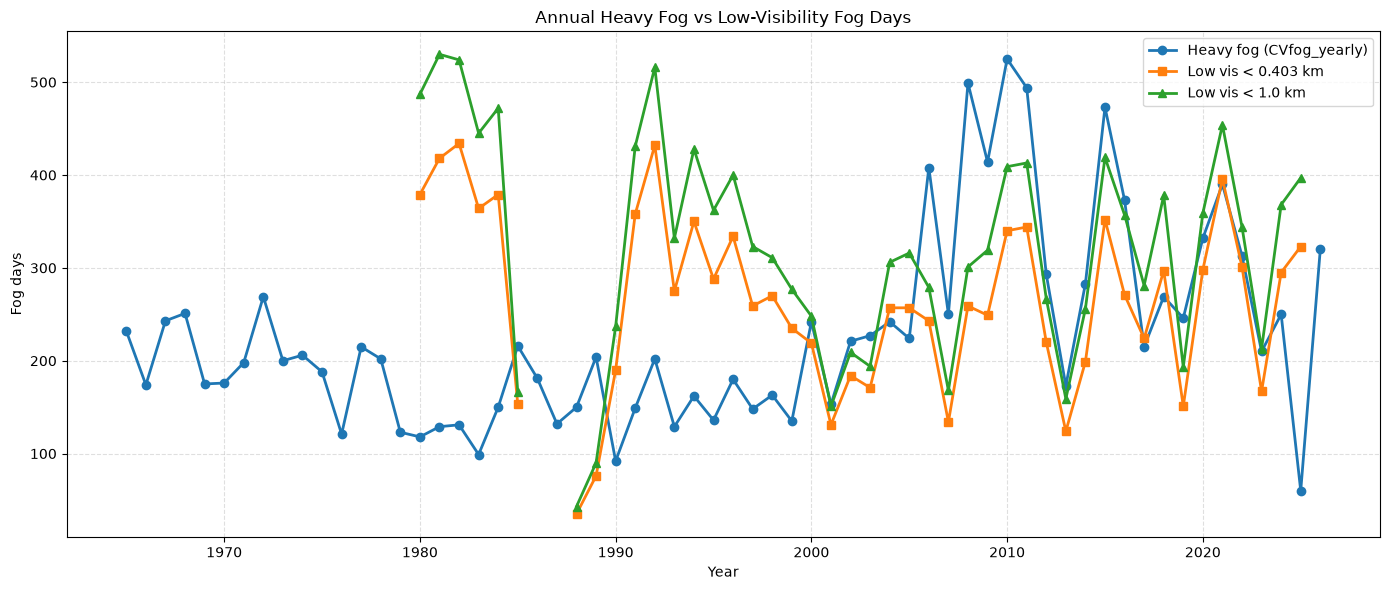

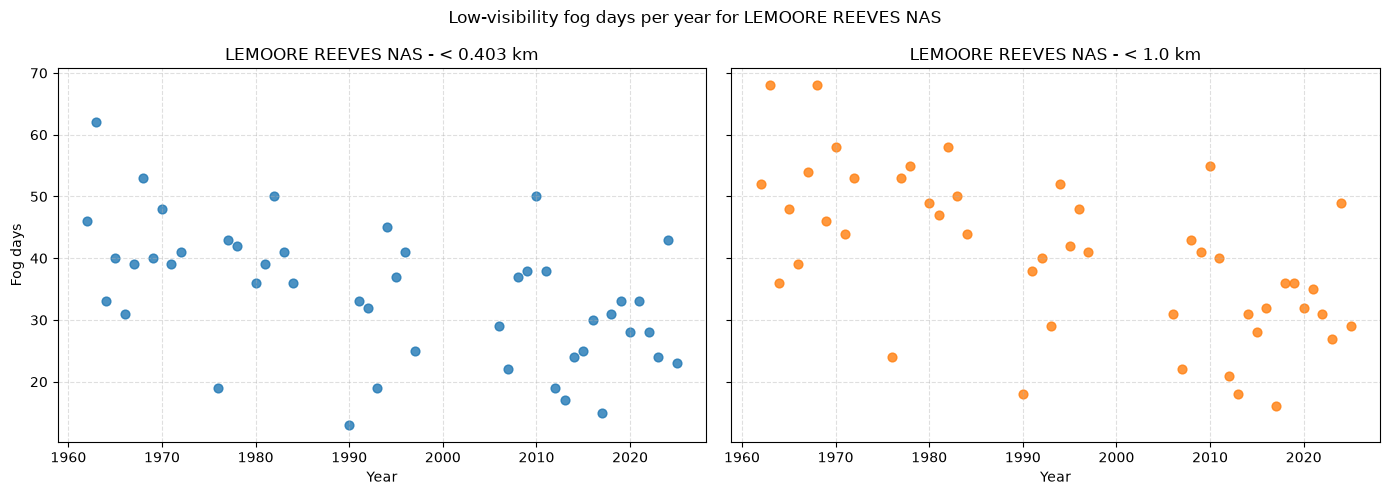

In [43]:
station = "LEMOORE REEVES NAS"

df_h = low_vis_fog_days_year_filtered[
    low_vis_fog_days_year_filtered["STATION"] == station
].sort_values("year")

df_1km = low_vis_fog_days_year_filtered_1km[
    low_vis_fog_days_year_filtered_1km["STATION"] == station
].sort_values("year")

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

axes[0].scatter(df_h["year"], df_h["fog_days"], s=40, color="tab:blue", alpha=0.8)
axes[0].set_title(f"{station} - < 0.403 km")
axes[0].set_xlabel("Year")
axes[0].set_ylabel("Fog days")
axes[0].grid(True, linestyle="--", alpha=0.4)

axes[1].scatter(df_1km["year"], df_1km["fog_days"], s=40, color="tab:orange", alpha=0.8)
axes[1].set_title(f"{station} - < 1.0 km")
axes[1].set_xlabel("Year")
axes[1].grid(True, linestyle="--", alpha=0.4)

fig.suptitle("Low-visibility fog days per year for LEMOORE REEVES NAS")
plt.tight_layout()
plt.show()